In [12]:
# -------------------------------------------------------------------------------------
# Third party imports
# -------------------------------------------------------------------------------------
import copy
import glob
import importlib
import inspect
import os
import sys
import warnings
from datetime import datetime
import subprocess

import requests
from pathlib import Path

import astropy
import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as c
from astropy import units as u
from astropy import wcs
from astropy.constants import R_earth, R_sun
from astropy.coordinates import SkyCoord
from astropy.coordinates.builtin_frames import (
    FK5,
    GCRS,
    ICRS,
    BarycentricMeanEcliptic,
    BarycentricTrueEcliptic,
    GeocentricMeanEcliptic,
    GeocentricTrueEcliptic,
    HeliocentricEclipticIAU76,
    HeliocentricMeanEcliptic,
    HeliocentricTrueEcliptic,
)
from astropy.io import fits
from astropy.nddata import CCDData
from astropy.time import Time
from astropy.units import allclose as quantity_allclose
from ccdproc import wcs_project  # , Combiner
from matplotlib.colors import LogNorm
from tqdm import tnrange

import matplotlib

# from IPython.display import display, Markdown, clear_output

warnings.filterwarnings("ignore")

# Plot setup
matplotlib.rc("font", size=22, family="serif", weight="bold")
plt.rcParams["figure.figsize"] = [10, 4]
np.printoptions(suppress=True)

In [9]:
# Local imports
sys.path.append(os.path.join(os.path.split(os.getcwd())[0], "shifty"))
import imagehandler
import cleaner

### TESS

In [11]:
"""
Below is some example code for downloading all images from one TESS frame and cleaning them
using the approach described in Alexandersen et al. 2026.
"""

# Define which sector/camera/ccd to look at
sector = 5
camera = 1
ccd = 4
# Define the name of the download script.
download_script = f"tesscurl_sector_{sector}_ffic.sh"

# Here we're going to grab the download script for all of the sector,
# filtering it to only get the camera/ccd that we want. 
with requests.get(f"https://archive.stsci.edu/missions/tess/download_scripts/sector/{download_script}") as r:
    r.raise_for_status()
    with open(download_script, 'w') as f:
        for line in r.text.splitlines():
            if f"s0005-1-4" in line:
                print(line, file=f)

In [13]:
# Run the download script to download the images. 
# This will take a while.
subprocess.run(["/bin/bash", str(download_script)])
# This wil download 1196 fits images, so be patient.

KeyboardInterrupt: 

In [21]:
# Originally we used Eleanor to filter the images and remove ones with high background or poor image quality,
# but here we will just use the list of known good images.
good_images = Path("good_image_names.txt").read_text().splitlines()
Path("poor_quality").mkdir(parents=True, exist_ok=True)
for f in Path(".").glob("tess*_ffic.fits"):
    print(f)
    if str(f) not in good_images:
        f.replace(f.parent / "poor_quality" / f.name)
        print(f"{f} moved to {(f.parent / 'poor_quality' / f.name)}")

tess2018342052938-s0005-1-4-0125-s_ffic.fits
tess2018340092938-s0005-1-4-0125-s_ffic.fits
tess2018328055938-s0005-1-4-0125-s_ffic.fits
tess2018320212938-s0005-1-4-0125-s_ffic.fits
tess2018336092938-s0005-1-4-0125-s_ffic.fits
tess2018321125938-s0005-1-4-0125-s_ffic.fits
tess2018327185938-s0005-1-4-0125-s_ffic.fits
tess2018337175938-s0005-1-4-0125-s_ffic.fits
tess2018341155938-s0005-1-4-0125-s_ffic.fits
tess2018324162938-s0005-1-4-0125-s_ffic.fits
tess2018344155937-s0005-1-4-0125-s_ffic.fits
tess2018342175937-s0005-1-4-0125-s_ffic.fits
tess2018326082938-s0005-1-4-0125-s_ffic.fits
tess2018342082938-s0005-1-4-0125-s_ffic.fits
tess2018341032938-s0005-1-4-0125-s_ffic.fits
tess2018321085938-s0005-1-4-0125-s_ffic.fits
tess2018341205938-s0005-1-4-0125-s_ffic.fits
tess2018325095938-s0005-1-4-0125-s_ffic.fits
tess2018325142938-s0005-1-4-0125-s_ffic.fits
tess2018341055938-s0005-1-4-0125-s_ffic.fits
tess2018341235938-s0005-1-4-0125-s_ffic.fits
tess2018331065938-s0005-1-4-0125-s_ffic.fits
tess201834

In [75]:
filenames = sorted(Path(".").glob("tess*_ffic.fits"))[0:200:]
print(len(filenames), "files")
C = cleaner.DataCleaner(filenames, extno=1, EXPTIME="EXPOSURE", EXPUNIT="d", MAGZERO=18.0,
                        MJD_START="BJDREFI+TSTART+-2400000.5", GAIN="GAINA", FILTER="-Tess", verbose=False,
                        #xycuts=[44, 244, 0, 200]  # Uncomment this to work with just a small cutout.
                        )
# Note: MAGZERO=18.0 is not accurate, but it also doesn't get used anywhere. When I made the method, I thought it would be...

# Do rough alignment (to pixel precision, without reprojection)
# TESS is usually already aligned to this level, but it's here to be sure, since the reprojection is faster if this is done first.
C.rough_align(0)
# Align by reprojecting/resampling the data onto the pixel grid of image 0 using the WCS of each image.
# (they'll thus have identical WCS afterwards and we can work in pixel space.)
C.reproject_data(0)
# Save this step
C.save_cleaned("clean00")

200 files
Reading image 199: tess2018343115937-s0005-1-4-0125-s_ffic.fits
Read 200 files!


KeyboardInterrupt: 

In [26]:
"""
Subtract the median background level from each images.

Uncomment the commented out lines to start from input files rather than an inherited cleaner objects. 
"""

#filenames = sorted(Path('.').glob("clean00*.fits"))[0::]
#print(len(filenames), "files")
#C = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d", MAGZERO=18.0,
#                        MJD_START="BJDREFI+TSTART+-2400000.5", GAIN="GAINA", FILTER="-Tess", verbose=False)
C.subtract_background_level(mode='median')
C.save_cleaned("clean01")

20 files
Reading image 19: clean00b_09.fits
Read 20 files!
Done!
Subtracting background level in image 19
Done
2

Done!


0.008483966144340748
3

Done!


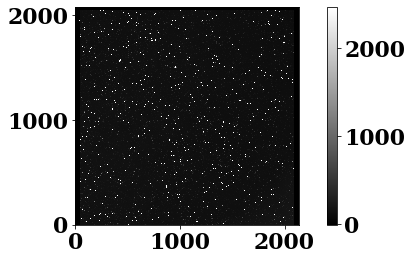

In [77]:
"""
Mask bright pixels and print the fraction of pixels masked.

Uncomment the commented out lines to start from input files rather than an inherited cleaner objects. 
"""

#filenames = sorted(Path('.').glob("clean01*.fits"))[0::]
#print(len(filenames), "files")
#C = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d", MAGZERO=18.0,
#                        MJD_START="BJDREFI+TSTART+-2400000.5", GAIN="GAINA", FILTER="-Tess", verbose=False)
C.mask_bright_sources(20000, 3.0)  # Large mask around very bright sources
C.mask_bright_sources(2000, 1.0)  # Smaller mask around lesser bright sources
# Print fraction of pixels 
print(np.sum(np.isnan(C.cleaned_data.data))/(np.product(np.shape(C.cleaned_data.data))))
C.save_cleaned("clean02")
# Plot
fig, ax = plt.subplots(1, 1)
im=ax.imshow(C.cleaned_data.data[-5], interpolation='nearest', cmap='gray', origin='lower', vmin=np.nanmin(C.cleaned_data.data[-5]), vmax=np.nanmax(C.cleaned_data.data[-5]))
fig.colorbar(im, ax=ax)

In [ ]:
"""
Do the donut template subtraction.

Since there is a big time gap in the middle of the sector, the donut template should not straddle this gap. 
We thus do donut subtraction of the two halves separately.
We therefore have to read each half into separate cleaner objects, rather than using the inherited cleaner object from above.
"""
filenames = sorted(Path('.').glob("clean02*.fits"))[0:547:]
print(len(filenames), "files")
D1 = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d", MAGZERO=18.0,
                        MJD_START="BJDREFI+TSTART+-2400000.5", GAIN="GAINA", FILTER="-Tess", verbose=False)
D1.subtract_background_level(mode='median')
D1.template_subtract('donut', usemean=False, ninner=4, nouter=10)  # ninner = h, nouter = h + d
D1.subtract_background_level(mode='sep')
D1.save_cleaned("clean03a")

# Second half
filenames = sorted(Path('.').glob("clean02*.fits"))[547::]
print(len(filenames), "files")
D2 = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d", MAGZERO=18.0,
                        MJD_START="BJDREFI+TSTART+-2400000.5", GAIN="GAINA", FILTER="-Tess", verbose=False)
D2.subtract_background_level(mode='median')
D2.template_subtract('donut', usemean=False, ninner=4, nouter=10)
D2.subtract_background_level(mode='sep')
D2.save_cleaned("clean03b")

# Plot
fig, ax = plt.subplots(1, 1)
im=ax.imshow(D1.cleaned_data.data[-5], interpolation='nearest', cmap='gray', origin='lower', vmin=np.nanmin(D1.cleaned_data.data[-5]), vmax=np.nanmax(D1.cleaned_data.data[-5]))
fig.colorbar(im, ax=ax)

220 files
Reading image 219: clean02_199.fits
Read 220 files!
Done!
Subtracting background level in image 219
Done


In [39]:
"""
Do the final background subtraction using three separate methods.

- Source Extractor Background Estimator.
- median
- mean
"""
filenames = sorted(Path('.').glob("clean03*.fits"))[0::]
print(len(filenames), "files")
F1 = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d", MAGZERO=18.0,
                        MJD_START="BJDREFI+TSTART+-2400000.5", GAIN="GAINA", FILTER="-Tess", verbose=False)
F2=copy.deepcopy(F1)
F3=copy.deepcopy(F1)
F1.subtract_background_level(mode='sep')
F1.save_cleaned("clean04_sep")
F2.subtract_background_level(mode='median')
F2.save_cleaned("clean04_median")
F3.subtract_background_level(mode='mean')
F3.save_cleaned("clean04_mean")

35 files
Reading image 34: clean03b_14.fits
Read 35 files!
Done!
Subtracting background level in image 34
Done
2

Done!
Subtracting background level in image 34
Done
2

Done!
Subtracting background level in image 34
Done
2

Done!


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
im=ax[0].imshow(F1.cleaned_data.data[-5], interpolation='nearest', cmap='gray', origin='lower', vmin=np.nanmin(F1.cleaned_data.data[-5]), vmax=np.nanmax(F1.cleaned_data.data[-5]))
fig.colorbar(im, ax=ax[0])
im=ax[1].imshow(F2.cleaned_data.data[-5], interpolation='nearest', cmap='gray', origin='lower', vmin=np.nanmin(F2.cleaned_data.data[-5]), vmax=np.nanmax(F2.cleaned_data.data[-5]))
fig.colorbar(im, ax=ax[1])
im=ax[2].imshow(F3.cleaned_data.data[-5], interpolation='nearest', cmap='gray', origin='lower', vmin=np.nanmin(F3.cleaned_data.data[-5]), vmax=np.nanmax(F3.cleaned_data.data[-5]))
fig.colorbar(im, ax=ax[2])

In [70]:
F1.cleaned_data.data[1,0:5,0:5]

array([[-0.2820754 , -0.18975693, -0.18251574, -0.16581398, -0.1260007 ],
       [-0.2762152 , -0.27662647, -0.2138452 , -0.18657106, -0.19052207],
       [-0.27558023, -0.17115045, -0.22734398, -0.26627958, -0.20733553],
       [-0.25178868, -0.2433539 , -0.19737649, -0.25749314, -0.09556937],
       [-0.17459774, -0.20202297, -0.20093882, -0.1466316 , -0.16198596]],
      dtype=float32)

In [71]:
F2.cleaned_data.data[1,0:5,0:5]

array([[-0.79378587, -0.6965074 , -0.6842614 , -0.6625114 , -0.617608  ],
       [-0.7870371 , -0.78250116, -0.71472806, -0.6824189 , -0.6812931 ],
       [-0.785505  , -0.67614096, -0.7273558 , -0.7612696 , -0.69726235],
       [-0.7608083 , -0.7474523 , -0.6965094 , -0.7516177 , -0.58464426],
       [-0.68270427, -0.7052215 , -0.6991852 , -0.6398832 , -0.6502016 ]],
      dtype=float32)

In [72]:
F3.cleaned_data.data[1,0:5,0:5]

array([[-0.783775  , -0.6864965 , -0.6742505 , -0.6525005 , -0.6075971 ],
       [-0.7770262 , -0.77249026, -0.70471716, -0.672408  , -0.6712822 ],
       [-0.7754941 , -0.66613007, -0.7173449 , -0.75125873, -0.68725145],
       [-0.7507974 , -0.7374414 , -0.6864985 , -0.74160683, -0.57463336],
       [-0.6726934 , -0.6952106 , -0.6891743 , -0.6298723 , -0.6401907 ]],
      dtype=float32)

In [73]:
print(np.nanmedian(F1.cleaned_data.data[0]),np.nanmean(F2.cleaned_data.data[0]),np.nanmean(F3.cleaned_data.data[0]))

0.08174742 0.863238 0.33866456
